### **Importing Libraries**

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import (
    leaguedashplayerstats,
)

### **Changing Options for Pandas**

- Applying `set_option()` to show max numbers of *columns* and *rows* on dataframes 

In [27]:
pd.set_option("display.max_columns", None, "display.max_rows", None)

### **Creating DataFrame for the Leagues Advance Stats**

- `leaguestats_adv[['PLAYER_NAME', 'USG_PCT']].sample(5)` grabs the player and their usage percentage

In [28]:
leaguestats_adv = leaguedashplayerstats.LeagueDashPlayerStats(
    season="2025-26",
    season_type_all_star="Regular Season",
    per_mode_detailed="Totals",
    measure_type_detailed_defense="Advanced",
).get_data_frames()[0]

leaguestats_adv[['PLAYER_NAME', 'USG_PCT']].sample(5)

,PLAYER_NAME,USG_PCT
263,Jaylin Williams,0.153
545,Tristan da Silva,0.160
132,De'Anthony Melton,0.244
119,Daniel Gafford,0.151
43,Bennedict Mathurin,0.246


### **Data Binning**

- `pd.cut()` is a method in the pandas library to *cut* and *split* apart data
- It's splitting it into three group:
    - `Low Usage:` players with a usage rate between 0-0.15
    - `Medium Usage:` players with a usage rate between 0.15-0.25
    - `High Usage:` players with a usage rate between 0.25-1.0

In [49]:
leaguestats_adv['usage_tier'] = pd.cut(
    leaguestats_adv['USG_PCT'],
    bins=[0, 0.15, 0.25, 1.0],
    labels=['Low Usage', 'Medium Usage', 'High Usage']
)

### **Creating Table for the `usage_tier`**

- Collecting data to see how many players are in each usage tier

In [61]:
leaguestats_adv.groupby('usage_tier')['usage_tier'].agg(['count']).reset_index()

,usage_tier,count
0,Low Usage,191
1,Medium Usage,329
2,High Usage,62


### **Data Aggregation**

- This combines the `TS_PCT` (True Shooting %) into the previous `usage_tier` table with the `USG_PCT` (Usage %)
- Shows the *true shooting %* of the players within their *usage tiers*

In [44]:
leaguestats_adv.groupby('usage_tier')['TS_PCT'].agg(['mean', 'count']).reset_index()

,usage_tier,mean,count
0,Low Usage,0.566937,191
1,Medium Usage,0.558711,329
2,High Usage,0.585210,62


### **Filtering Players**
- `[leaguestats_adv['FGA'] >= 100]` Filters out players who haven't taken 100 shots or more

In [34]:
leaguestats_filtered = leaguestats_adv[leaguestats_adv['FGA'] >= 100]

### **Updated Table**

- Revealing the table after filtering out players who haven't took many shots during the season

In [37]:
leaguestats_filtered.groupby('usage_tier')['TS_PCT'].agg(['mean', 'count', 'std']).reset_index()

,usage_tier,mean,count,std
0,Low Usage,0.582899,109,0.067105
1,Medium Usage,0.571387,261,0.050795
2,High Usage,0.587982,57,0.037370


### **Plotting the Table**

- Showing a visual representation of players within different **usage rates** stack up against their **true shooting percentages**
- Also revealing the **standard deviation** between the tiers using shaded colors

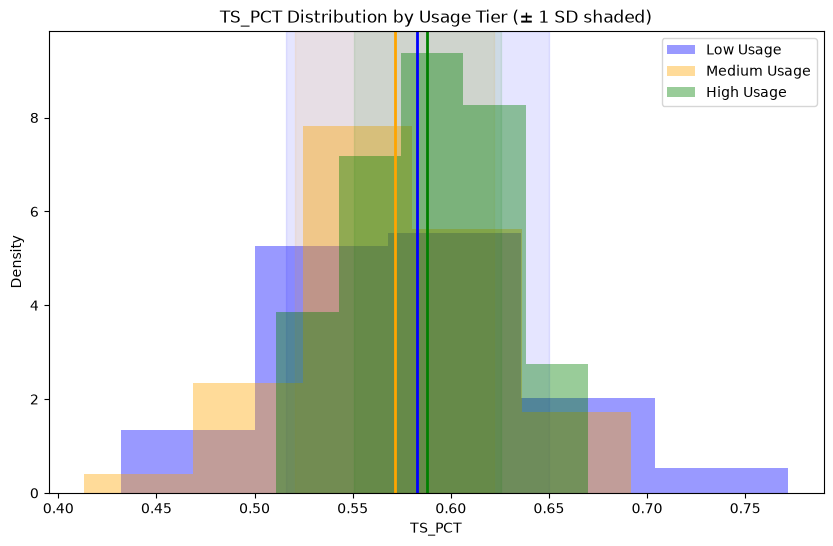

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Low Usage': 'blue', 'Medium Usage': 'orange', 'High Usage': 'green'}

for tier, color in colors.items():
    subset = leaguestats_filtered[leaguestats_filtered['usage_tier'] == tier]['TS_PCT']
    mean_val = subset.mean()
    std_val = subset.std()

    ax.hist(subset, bins=5, alpha=0.4, density=True, color=color, label=tier)
    ax.axvline(mean_val, color=color, linestyle='-', linewidth=2)
    ax.axvspan(mean_val - std_val, mean_val + std_val, color=color, alpha=0.1)

ax.set_title('TS_PCT Distribution by Usage Tier (± 1 SD shaded)')
ax.set_xlabel('TS_PCT')
ax.set_ylabel('Density')
ax.legend()
plt.show()